## Connecting to Wandb

In [3]:
import wandb
import pandas as pd
import os

wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/gl/.netrc
wandb: Currently logged in as: latora (the-golfers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
ENTITY = "the-golfers"
PROJECT = "ml_ai_project"

### Getting all useful models for this analysis from Wandb

In [34]:
api = wandb.Api()

# Get runs containing either string in the run name
filtered_runs = []

for run in api.runs(f"{ENTITY}/{PROJECT}"):

    run_name = run.name.lower()

    if (
        "golf_baseline_quan" in run_name
        or "golf_baseline_giulio_quantization_no_embedding_seed" in run_name
    ):
        filtered_runs.append(run)

print(f"Found {len(filtered_runs)} runs")

# Collect summary metrics
rows = []

for run in filtered_runs:
    row = {
        "run_id": run.id,
        "run_name": run.name,
        "state": run.state,
        "created_at": run.created_at,
    }

    # Add summary metrics
    for key, value in run.summary.items():
        if not key.startswith("_"):
            row[key] = value

    rows.append(row)

# Convert to dataframe
df = pd.DataFrame(rows)

# Show first rows
df.head()

Found 18 runs


,run_id,run_name,state,created_at,final_val_bpb,final_val_loss,lr_scale,quant_baseline_bytes,quant_compression_ratio,quant_file_bytes,quant_int8_payload_bytes,quant_num_float_tensors,quant_param_count,tokens_seen,train_loss,val_bpb,val_loss
0,9dclcs72,golf_baseline_giulio_quantization_no_embedding...,finished,2026-05-10T16:46:29Z,1.310351,2.212473,0.001333,67191072,3.911253,15767882,17178912,55,17059912,655360000,2.129117,1.306479,2.205935
1,ay191x5l,golf_baseline_giulio_quantization_no_embedding...,finished,2026-05-10T16:46:46Z,1.311622,2.214618,0.001333,67191072,3.911253,15777956,17178912,55,17059912,655360000,2.130994,1.307766,2.208108
2,8qf6uzkw,golf_baseline_giulio_quantization_no_embedding...,finished,2026-05-10T16:46:57Z,1.309119,2.210393,0.001333,67191072,3.911253,15792356,17178912,55,17059912,655360000,2.123003,1.305421,2.204149
3,9t3s6c5c,golf_baseline_quantiztion_no_firsttransformerb...,finished,2026-05-12T08:19:56Z,1.309259,2.210628,0.001333,67191072,2.962858,20914221,22677792,49,17059912,655360000,2.127769,1.305610,2.204468
4,1hms1y7d,golf_baseline_quantiztion_no_firsttransformerb...,finished,2026-05-12T08:57:40Z,1.310477,2.212685,0.001333,67191072,2.962858,20916624,22677792,49,17059912,655360000,2.128028,1.306840,2.206544


In [35]:
df

,run_id,run_name,state,created_at,final_val_bpb,final_val_loss,lr_scale,quant_baseline_bytes,quant_compression_ratio,quant_file_bytes,quant_int8_payload_bytes,quant_num_float_tensors,quant_param_count,tokens_seen,train_loss,val_bpb,val_loss
0,9dclcs72,golf_baseline_giulio_quantization_no_embedding...,finished,2026-05-10T16:46:29Z,1.310351,2.212473,0.001333,67191072,3.911253,15767882,17178912,55,17059912,655360000,2.129117,1.306479,2.205935
1,ay191x5l,golf_baseline_giulio_quantization_no_embedding...,finished,2026-05-10T16:46:46Z,1.311622,2.214618,0.001333,67191072,3.911253,15777956,17178912,55,17059912,655360000,2.130994,1.307766,2.208108
2,8qf6uzkw,golf_baseline_giulio_quantization_no_embedding...,finished,2026-05-10T16:46:57Z,1.309119,2.210393,0.001333,67191072,3.911253,15792356,17178912,55,17059912,655360000,2.123003,1.305421,2.204149
3,9t3s6c5c,golf_baseline_quantiztion_no_firsttransformerb...,finished,2026-05-12T08:19:56Z,1.309259,2.210628,0.001333,67191072,2.962858,20914221,22677792,49,17059912,655360000,2.127769,1.305610,2.204468
4,1hms1y7d,golf_baseline_quantiztion_no_firsttransformerb...,finished,2026-05-12T08:57:40Z,1.310477,2.212685,0.001333,67191072,2.962858,20916624,22677792,49,17059912,655360000,2.128028,1.306840,2.206544
5,oufg9dmu,golf_baseline_quantiztion_no_firsttransformerb...,finished,2026-05-12T09:35:09Z,1.308397,2.209173,0.001333,67191072,2.962858,20922013,22677792,49,17059912,655360000,2.125730,1.304592,2.202749
6,ha9e4c8t,golf_baseline_quantiztion_embeddingandoutputhe...,finished,2026-05-12T13:26:41Z,1.306293,2.205621,0.001333,67191072,3.583576,16220165,18749728,54,17059912,655360000,2.127198,1.306169,2.205412
7,s3pmag6c,golf_baseline_quantiztion_embeddingandoutputhe...,finished,2026-05-12T14:04:28Z,1.307916,2.208362,0.001333,67191072,3.583576,16200330,18749728,54,17059912,655360000,2.130392,1.307781,2.208133
8,bdm2sidy,golf_baseline_quantiztion_embeddingandoutputhe...,finished,2026-05-12T14:42:36Z,1.305247,2.203854,0.001333,67191072,3.583576,16210877,18749728,54,17059912,655360000,2.126666,1.305130,2.203657
9,d9yjzcnp,golf_baseline_quantization_no_lasttransformerb...,finished,2026-05-13T12:58:17Z,1.308949,2.210106,0.001333,67191072,2.962858,20953323,22677792,49,17059912,655360000,2.125818,1.305314,2.203967


## Layer Sensitivity Study

### We take the baseline model, it presents a quantization that transforms all that is not: attn_scale,attn_scales,mlp_scale,mlp_scales,resid_mix,resid_mixes,q_gain,skip_weight,skip_weights into int8 numbers after training. 

### In this study, we quantize as with the quantization method of the baseline excluding different parst of the model to see how much the model improves by having a higher precision with the excluded parts.

### We check for not having quantized these different parts: (the embedding and output heads), (the first transformer block), (the last transformer block), (the attention of all transformer blocks), (the mlp of all transformer blocks)

Taking useful data from summary metrics i.e. final_val_bpb and quant_file_bytes

In [36]:
df_quantization = df[[
    "run_name",
    "final_val_bpb",
    "quant_file_bytes",
]]


In [37]:
df_quantization

,run_name,final_val_bpb,quant_file_bytes
0,golf_baseline_giulio_quantization_no_embedding...,1.310351,15767882
1,golf_baseline_giulio_quantization_no_embedding...,1.311622,15777956
2,golf_baseline_giulio_quantization_no_embedding...,1.309119,15792356
3,golf_baseline_quantiztion_no_firsttransformerb...,1.309259,20914221
4,golf_baseline_quantiztion_no_firsttransformerb...,1.310477,20916624
5,golf_baseline_quantiztion_no_firsttransformerb...,1.308397,20922013
6,golf_baseline_quantiztion_embeddingandoutputhe...,1.306293,16220165
7,golf_baseline_quantiztion_embeddingandoutputhe...,1.307916,16200330
8,golf_baseline_quantiztion_embeddingandoutputhe...,1.305247,16210877
9,golf_baseline_quantization_no_lasttransformerb...,1.308949,20953323


Computing means and variance out of the 3 seeds we had 

In [40]:
df_subset = df_quantization.reset_index(drop=True)

group_ids = df_subset.index // 3

df_stats = (
    df_subset
    .groupby(group_ids)
    .agg(
        run_name=("run_name", "first"),

        final_val_bpb=("final_val_bpb", "mean"),
        quant_file_bytes=("quant_file_bytes", "mean"),

        final_val_bpb_var=("final_val_bpb", "var"),
        quant_file_bytes_var=("quant_file_bytes", "var"),
    )
    .reset_index(drop=True)
)

df_mean = df_stats

Fixing the names of the models

In [41]:
# Rename the first model
df_mean.loc[
    df_mean["run_name"].str.contains(
        "golf_baseline_giulio_quantization_no_embedding",
        na=False
    ),
    "run_name"
] = "golf_baseline_quantization_seed1337"

# Fix typo: quantiztion -> quantization
df_mean["run_name"] = df_mean["run_name"].str.replace(
    "quantiztion",
    "quantization",
    regex=False
)

df_mean.loc[
    df_mean["run_name"] == "golf_baseline_quantization_embeddingandoutputhead",
    "run_name"
] = "golf_baseline_quantization_no_embeddingandoutputhead"

df_mean

# Show updated dataframe
df_mean

,run_name,final_val_bpb,quant_file_bytes,final_val_bpb_var,quant_file_bytes_var
0,golf_baseline_quantization_seed1337,1.310364,1.577940e+07,1.565650e-06,1.513037e+08
1,golf_baseline_quantization_no_firsttransformer...,1.309377,2.091762e+07,1.092003e-06,1.592183e+07
2,golf_baseline_quantization_embeddingandoutputh...,1.306485,1.621046e+07,1.809601e-06,9.848890e+07
3,golf_baseline_quantization_no_lasttransformerb...,1.309631,2.094956e+07,1.014671e-06,8.954529e+07
4,golf_baseline_quantization_no_attention_seed1337,1.309601,3.554033e+07,6.126104e-07,3.562629e+07
5,golf_baseline_quantization_no_mlp_seed1337,1.310050,2.904397e+07,1.242759e-06,3.741276e+06


In [42]:
df_mean["run_name"] = df_mean["run_name"].str.replace(
    "_seed1337",
    "",
    regex=False
)

df_mean

,run_name,final_val_bpb,quant_file_bytes,final_val_bpb_var,quant_file_bytes_var
0,golf_baseline_quantization,1.310364,1.577940e+07,1.565650e-06,1.513037e+08
1,golf_baseline_quantization_no_firsttransformer...,1.309377,2.091762e+07,1.092003e-06,1.592183e+07
2,golf_baseline_quantization_embeddingandoutputhead,1.306485,1.621046e+07,1.809601e-06,9.848890e+07
3,golf_baseline_quantization_no_lasttransformerb...,1.309631,2.094956e+07,1.014671e-06,8.954529e+07
4,golf_baseline_quantization_no_attention,1.309601,3.554033e+07,6.126104e-07,3.562629e+07
5,golf_baseline_quantization_no_mlp,1.310050,2.904397e+07,1.242759e-06,3.741276e+06


### 

#### We plot in the Val_BPB Quantized file size space all of the different quantized models and the baseline. 

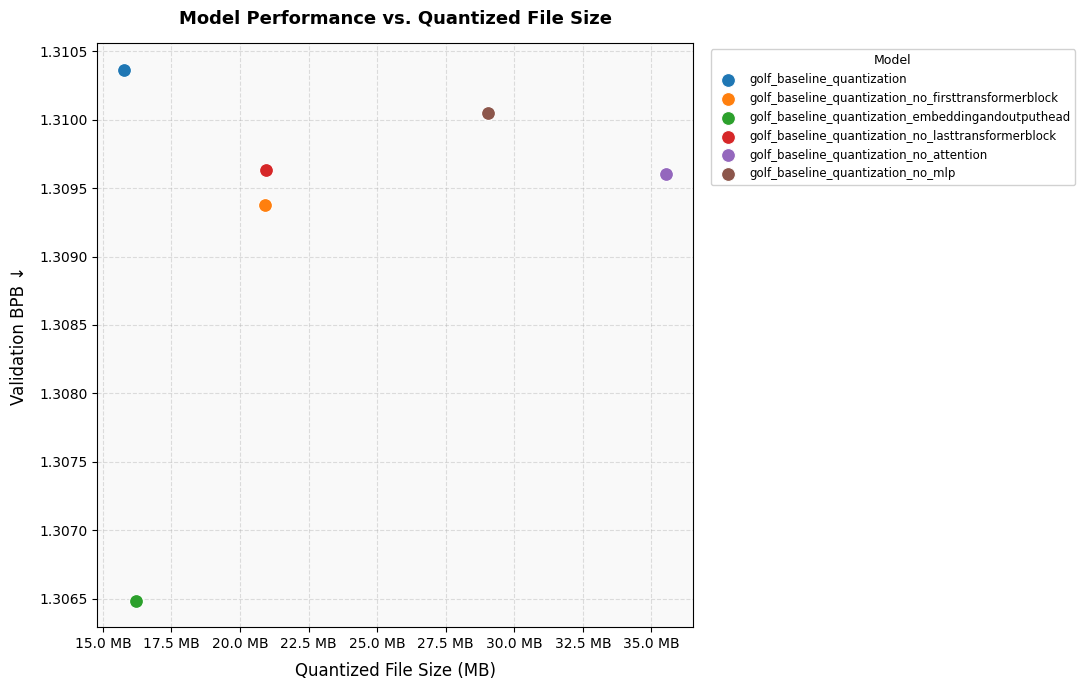

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(11, 7))

# Plot each point individually so we can assign legend labels
for _, row in df_mean.iterrows():
    ax.scatter(
        row["quant_file_bytes"] / 1e6,
        row["final_val_bpb"],
        s=100,
        edgecolors="white",
        linewidths=0.8,
        zorder=3,
        label=row["run_name"],
    )

# Legend on the side
ax.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8.5,
    title_fontsize=9,
    framealpha=0.9,
)

# Labels, grid, style
ax.set_xlabel("Quantized File Size (MB)", fontsize=12, labelpad=8)
ax.set_ylabel("Validation BPB ↓", fontsize=12, labelpad=8)
ax.set_title("Model Performance vs. Quantized File Size", fontsize=13, fontweight="bold", pad=14)
ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f MB"))

plt.tight_layout()
plt.savefig("model_size_vs_bpb.png", dpi=150, bbox_inches="tight")
plt.show()

Same plot as above but showing the variance as well

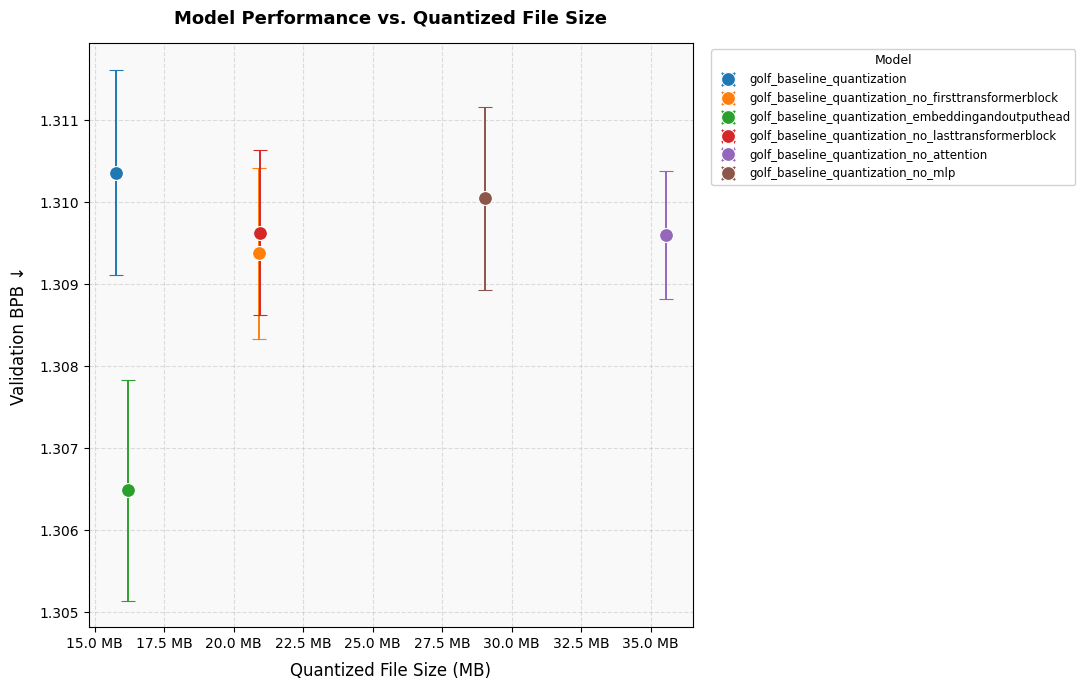

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(11, 7))

for _, row in df_stats.iterrows():
    x = row["quant_file_bytes"] / 1e6
    y = row["final_val_bpb"]

    xerr = np.sqrt(row["quant_file_bytes_var"]) / 1e6
    yerr = np.sqrt(row["final_val_bpb_var"])

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        markersize=10,
        capsize=5,
        elinewidth=1.4,
        markeredgecolor="white",
        markeredgewidth=0.8,
        zorder=3,
        label=row["run_name"],
    )

ax.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8.5,
    title_fontsize=9,
    framealpha=0.9,
)

ax.set_xlabel("Quantized File Size (MB)", fontsize=12, labelpad=8)
ax.set_ylabel("Validation BPB ↓", fontsize=12, labelpad=8)
ax.set_title("Model Performance vs. Quantized File Size", fontsize=13, fontweight="bold", pad=14)
ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f MB"))

plt.tight_layout()
plt.savefig("model_size_vs_bpb_with_variance.png", dpi=150, bbox_inches="tight")
plt.show()

##### We conclude that leaving unquatized the embeddings and the output heads gives the biggest increase in validation while being the smallest in term of byte increase. The next best increase in validation was from the first and last transformer block which share the same byte size (clearly as we have the same number of weights), the first transformer block model has slightly lower validation but this difference is probably due to chance. Unexpectedly the mlp and attention models did not produce better validation results than just the transformer block models even having a much heigher byte count. This shows that just unquatizing random weights in the model or even big chuncks of the model in the does not lead to significant increases in model performance.